In [1]:

# ------------------- Général ------------------- #
import requests
import zipfile
import io
from pathlib import Path
import joblib
import os
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import re
import unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------- ScitKit Learn ------------------- #

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate


# ------------ Modélisation & Algorithmes de classification

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# PCA
import prince
import warnings
import time


SEED = 42

In [2]:
DATA_DIR = "../data"
TARGET = "consommation"
DATA_DIR_PATH = Path(DATA_DIR)
BASE_URL = (
    "https://eco2mix.rte-france.com/download/eco2mix/"
    "eCO2mix_RTE_Annuel-Definitif_{year}.zip"
)
SUPPORTED_EXTENSIONS = [".csv", ".xls", ".xlsx"]

START_YEAR = 2019
END_YEAR =  2022
TRAIN_YEARS = [2019, 2020, 2021]
TEST_YEARS = [2022]

CITIES = {
    "Paris": (48.8566, 2.3522),
    "Marseille": (43.2965, 5.3698),
    "Bordeaux": (44.8378, -0.5792),
    "Brest": (48.3904, -4.4861),
    "Clermont-Ferrand": (45.7772, 3.0870),
    "Dijon": (47.3220, 5.0415),
    "Grenoble": (45.1885, 5.7245),
    "Lille": (50.6292, 3.0573),
    "Metz": (49.1193, 6.1757),
    "Montpellier": (43.6108, 3.8767),
    "Toulon": (43.1242, 5.9280),
    "Nancy": (48.6921, 6.1844),
    "Nantes": (47.2184, -1.5536),
    "Nice": (43.7102, 7.2620),
    "Orléans": (47.9029, 1.9093),
    "Rennes": (48.1173, -1.6778),
    "Rouen": (49.4431, 1.0993),
    "Saint-Etienne": (45.4397, 4.3872),
    "Strasbourg": (48.5734, 7.7521),
    "Toulouse": (43.6047, 1.4442),
    "Tours": (47.3941, 0.6848),
}

In [3]:
COLUMN_RENAME = {
    "hydraulique_fil_de_leeau_eclusee": "hydraulique_fil_de_leau_eclusee",
}

EXPECTED_COLS = [
    "perimetre","nature","date","heures","consommation",
    "prevision_j_1","prevision_j","fioul","charbon","gaz",
    "nucleaire","eolien","solaire","hydraulique","pompage",
    "bioenergies","ech_physiques","taux_de_co2",
    "ech_comm_angleterre","ech_comm_espagne",
    "ech_comm_italie","ech_comm_suisse",
    "ech_comm_allemagne_belgique",
    "fioul_tac","fioul_cogen","fioul_autres",
    "gaz_tac","gaz_cogen","gaz_ccg","gaz_autres",
    "hydraulique_fil_de_leau_eclusee",
    "hydraulique_lacs","hydraulique_step_turbinage",
    "bioenergies_dechets","bioenergies_biomasse",
    "bioenergies_biogaz","stockage_batterie",
    "destockage_batterie","eolien_terrestre",
    "eolien_offshore","source_file"
]


In [4]:
def download_and_extract(
    start_year: int = 2012,
    target_dir: str = "./src/data_folder"
) -> list[Path]:
    """
    Télécharge et dézippe automatiquement les données éCO2mix annuelles
    depuis start_year jusqu'à la dernière année disponible.

    - S'arrête dès qu'une année n'est plus disponible
    - Extrait les fichiers directement dans data
    - Évite les doublons
    """

    DATA_DIR_PATH.mkdir(parents=True, exist_ok=True)

    extracted_files = []
    year = start_year

    while True:
        url = BASE_URL.format(year=year)
        print(f"Vérification : {url}")

        response = requests.get(url)

        if response.status_code != 200:
            print(f"Fin de téléchargement à l'année {year - 1}")
            break

        print(f"download : {year}")

        with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
            for member in zip_file.namelist():
                output_file = DATA_DIR_PATH / member

                # Éviter de réécrire si le fichier existe déjà
                if output_file.exists():
                    print(f"Fichier déjà présent : {output_file.name}")
                    continue

                zip_file.extract(member, DATA_DIR_PATH)
                extracted_files.append(output_file)

        year += 1

    return extracted_files

In [5]:
def _clean_colname(col: str) -> str:
    if not isinstance(col, str):
        col = str(col)

    col = col.strip()
    col = col.replace("�", "e").replace("?", "e")

    col = unicodedata.normalize("NFKD", col)
    col = col.encode("ascii", "ignore").decode("ascii")

    col = col.lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")

    return col

In [6]:
def _load_single_file(filepath: Path) -> pd.DataFrame:
    suffix = filepath.suffix.lower()

    def read_csv_smart(path):
        best_df = None
        best_cols = 0

        for sep in [";", ",", "\t"]:
            try:
                df_try = pd.read_csv(
                    path,
                    sep=sep,
                    encoding="latin1",
                    low_memory=False,
                    dtype=str,
                    index_col=False
                )                
                if df_try.shape[1] > best_cols:
                    best_cols = df_try.shape[1]
                    best_df = df_try
            except Exception:
                continue

        if best_df is None or best_cols == 1:
            raise ValueError("Impossible de détecter le séparateur CSV")

        return best_df

    try:
        if suffix == ".xls":
                df = read_csv_smart(filepath)
    except Exception as e:
        raise RuntimeError(f"Erreur lors du chargement de {filepath.name} : {e}")

    # Nettoyage des colonnes
    df.columns = [_clean_colname(c) for c in df.columns]
    
    df["source_file"] = filepath.name

    return df


In [7]:
def aggregate_hourly(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.replace("ND", pd.NA)

    # datetime
    df["datetime"] = pd.to_datetime(
        df["date"].astype(str) + " " + df["heures"].astype(str),
        errors="coerce"
    )

    df["hour_ts"] = df["datetime"].dt.floor("h")

    numeric_cols = df.select_dtypes(include="number").columns
    non_numeric_cols = df.columns.difference(numeric_cols)

    agg_dict = {}

    for col in numeric_cols:
        agg_dict[col] = "mean"

    for col in non_numeric_cols:
        if col not in ["datetime", "hour_ts"]:
            agg_dict[col] = "first"

    hourly_df = (
        df.groupby("hour_ts")
          .agg(agg_dict)
          .reset_index()
          .rename(columns={"hour_ts": "datetime"})
    )

    return hourly_df



def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = aggregate_hourly(df)

    df["year"] = df["datetime"].dt.year
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.day
    df["month"] = df["datetime"].dt.month
    df["dayofweek"] = df["datetime"].dt.dayofweek
    df["weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    df.drop(columns=[
        "perimetre",
        "nature",
        "source_file",
        "date",
        "heures",
        "datetime"
    ], errors="ignore", inplace=True)
    
    df = df.fillna(0)

    return df


In [8]:
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # normalisation des valeurs invalides
    df = df.replace(["ND", "None", "nan", ""], pd.NA)

    # Normalisation des noms de colonnes foireux
    df = df.rename(columns=COLUMN_RENAME)

    # schéma imposé
    df = df.reindex(columns=EXPECTED_COLS)

    # Typage automatique
    for col in df.columns:
        converted = pd.to_numeric(df[col], errors="coerce")
        ratio_numeric = converted.notna().mean()

        if ratio_numeric > 0.3:
            df[col] = converted
        else:
            df[col] = df[col].astype("string")
            df[col] = df[col].where(df[col].notna(), None)

    return df

In [9]:
def f_plot_circle(pca, dataframe, figsize=(8,8)):
    """
    Affiche le cercle des corrélations des variables sur les deux premiers axes factoriels.
    """
    # Coordonnées des variables
    variable_coords = pca.column_coordinates_

    fig, axes = plt.subplots(figsize=figsize)

    # Afficher chaque variable comme un point et un nom
    for i, (x, y) in enumerate(zip(variable_coords[0], variable_coords[1])):
        # Utiliser plt.text pour éviter les points qui se chevauchent avec les labels
        plt.text(x, y, dataframe.columns[i], fontsize=10, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    # Cercle des corrélations
    cercle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--')
    axes.add_artist(cercle)

    # Axes
    plt.axhline(0, color='silver', linestyle='-', linewidth=1)
    plt.axvline(0, color='silver', linestyle='-', linewidth=1)

    # Configuration du graphique
    axes.set_xlim(-1.05, 1.05)
    axes.set_ylim(-1.05, 1.05)
    plt.title('Cercle des Corrélations PCA', fontsize=16)
    plt.xlabel('Composante Principale 1', fontsize=12)
    plt.ylabel('Composante Principale 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().set_aspect('equal', adjustable='box') # Assurer que le cercle est bien un cercle

    plt.show()

In [10]:
def plot_model_performance_distribution(results_df):
    """
    Crée des box plots pour visualiser la distribution de l'accuracy, du F1-score et du recall pour chaque modèle.

    Args:
        results_df (pd.DataFrame): Un DataFrame contenant les scores de chaque pli.
                                   Doit contenir les colonnes 'model', 'accuracy', 'f1', et 'recall'.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

    # Box plot pour l'Accuracy
    sns.boxplot(x='model', y='accuracy', data=results_df, ax=axes[0], palette='viridis')
    axes[0].set_title('Distribution de l\'Accuracy par Modèle (CV=5)', fontsize=14)
    axes[0].set_xlabel('Modèle', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)

    # Box plot pour le F1-Score
    sns.boxplot(x='model', y='f1', data=results_df, ax=axes[1], palette='plasma')
    axes[1].set_title('Distribution du F1-Score par Modèle (CV=5)', fontsize=14)
    axes[1].set_xlabel('Modèle', fontsize=12)
    axes[1].set_ylabel('F1-Score', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)

    # Box plot pour le Recall
    sns.boxplot(x='model', y='recall', data=results_df, ax=axes[2], palette='magma')
    axes[2].set_title('Distribution du Recall par Modèle (CV=5)', fontsize=14)
    axes[2].set_xlabel('Modèle', fontsize=12)
    axes[2].set_ylabel('Recall', fontsize=12)
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [11]:
def plot_feature_over_time(dt_index, feature_values, title, ylabel, color="steelblue", figsize=(12, 4)):
    """
    Plot a feature over time.
    
    Args:
        dt_index: DateTime index
        feature_values: Feature values to plot
        title: Title of the plot
        ylabel: Label for y-axis
        color: Line color (default: "steelblue")
        figsize: Figure size (default: (12, 4))
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(dt_index, feature_values, color=color, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Datetime")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()


In [12]:
def load_all_data(data_dir: str) -> pd.DataFrame:
    """
    Charge automatiquement tous les fichiers du dossier data/
    """
    data_path = Path(data_dir)

    if not data_path.exists():
        raise FileNotFoundError(f"Dossier introuvable : {data_dir}")

    all_dfs = []

    for file in data_path.iterdir():
        if file.suffix.lower() in SUPPORTED_EXTENSIONS:
            print(f"Chargement : {file.name}")
            df = _load_single_file(file)
            all_dfs.append(df)

    if not all_dfs:
        return pd.DataFrame()

    df_final = pd.concat(all_dfs, ignore_index=True)
    return df_final

## Fetch Météo Data

In [13]:
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"

all_cities_data = []

In [14]:
def fetch_weather(start_date= str, end_date= str) -> pd.DataFrame :

    for city, (lat, lon) in CITIES.items():
        
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": start_date,
            "end_date": end_date,
            "hourly": ["temperature_2m", "relative_humidity_2m", "snowfall", "precipitation", "weather_code"],
            "timezone": "Europe/London",
        }
        
        responses = openmeteo.weather_api(url, params=params)
        response = responses[0]
        
        print(f"Selected City : {city} ")


        hourly = response.Hourly()
        hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
        hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
        hourly_snowfall = hourly.Variables(2).ValuesAsNumpy()
        hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()
        hourly_weather_code = hourly.Variables(4).ValuesAsNumpy()

        hourly_data = {"date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        )}
        
        hourly_data["city"] = city
        hourly_data["temperature_2m"] = hourly_temperature_2m
        hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
        hourly_data["snowfall"] = hourly_snowfall
        hourly_data["precipitation"] = hourly_precipitation
        hourly_data["weather_code"] = hourly_weather_code

        city_df = pd.DataFrame(hourly_data)
        all_cities_data.append(city_df)
        
    return pd.concat(all_cities_data, ignore_index=True)

In [15]:
def ingest_weather(start_year=2012, end_year=2023):

    for year in range(start_year, end_year + 1):


        print("Fetch météo", year)

        start_date = f"{year}-01-01"
        end_date   = f"{year}-12-31"

        df = fetch_weather(start_date, end_date)

        # Nettoyage
        df["datetime"] = pd.to_datetime(df["date"])
        df = df.drop(columns=["date"])

        df = df[[
            "city",
            "datetime",
            "temperature_2m",
            "relative_humidity_2m",
            "snowfall",
            "precipitation",
            "weather_code"
        ]]

        print("Insertion météo", year)

        df = df.replace("ND", pd.NA)

        df = df.replace("NaN", pd.NA)

        print("Sleep")
        time.sleep(2)

    print("ingestion weather terminée")
    return df

In [16]:
df_tmp_meteo = pd.read_csv("../weather_data_202601301721.csv")

# Keep only years 2019 to 2023
df_tmp_meteo["datetime"] = pd.to_datetime(df_tmp_meteo["datetime"], errors="coerce")
df_meteo = df_tmp_meteo[df_tmp_meteo["datetime"].dt.year.between(2019, 2023)].copy()

df_meteo.head()

,id,city,datetime,temperature_2m,relative_humidity_2m,snowfall,precipitation,weather_code
6444648,6444649,Paris,2019-01-01 00:00:00,5.60,95.584831,0.0,0.0,2
6444649,6444650,Paris,2019-01-01 01:00:00,6.45,92.678398,0.0,0.0,3
6444650,6444651,Paris,2019-01-01 02:00:00,6.30,92.348312,0.0,0.0,3
6444651,6444652,Paris,2019-01-01 03:00:00,6.15,92.661377,0.0,0.0,3
6444652,6444653,Paris,2019-01-01 04:00:00,6.60,91.092300,0.0,0.0,3


In [17]:
extarcted_files = download_and_extract(start_year=START_YEAR, target_dir="data")
print(extarcted_files)

Vérification : https://eco2mix.rte-france.com/download/eco2mix/eCO2mix_RTE_Annuel-Definitif_2019.zip
download : 2019
Vérification : https://eco2mix.rte-france.com/download/eco2mix/eCO2mix_RTE_Annuel-Definitif_2020.zip
download : 2020
Vérification : https://eco2mix.rte-france.com/download/eco2mix/eCO2mix_RTE_Annuel-Definitif_2021.zip
download : 2021
Vérification : https://eco2mix.rte-france.com/download/eco2mix/eCO2mix_RTE_Annuel-Definitif_2022.zip
download : 2022
Vérification : https://eco2mix.rte-france.com/download/eco2mix/eCO2mix_RTE_Annuel-Definitif_2023.zip
download : 2023
Vérification : https://eco2mix.rte-france.com/download/eco2mix/eCO2mix_RTE_Annuel-Definitif_2024.zip
Fin de téléchargement à l'année 2023
[PosixPath('../data/eCO2mix_RTE_Annuel-Definitif_2019.xls'), PosixPath('../data/eCO2mix_RTE_Annuel-Definitif_2020.xls'), PosixPath('../data/eCO2mix_RTE_Annuel-Definitif_2021.xls'), PosixPath('../data/eCO2mix_RTE_Annuel-Definitif_2022.xls'), PosixPath('../data/eCO2mix_RTE_Annue

In [18]:
df_conso = load_all_data(DATA_DIR)
df_conso.head()

df_conso

Chargement : eCO2mix_RTE_Annuel-Definitif_2023.xls
Chargement : eCO2mix_RTE_Annuel-Definitif_2022.xls
Chargement : eCO2mix_RTE_Annuel-Definitif_2021.xls
Chargement : eCO2mix_RTE_Annuel-Definitif_2020.xls
Chargement : eCO2mix_RTE_Annuel-Definitif_2019.xls


,perimetre,nature,date,heures,consommation,prevision_j_1,prevision_j,fioul,charbon,gaz,...,hydraulique_lacs,hydraulique_step_turbinage,bioenergies_dechets,bioenergies_biomasse,bioenergies_biogaz,stockage_batterie,destockage_batterie,eolien_terrestre,eolien_offshore,source_file
0,France,Données définitives,2023-01-01,00:00,47571,46600,48000,81,24,2418,...,1224,743,534,431,333,0,0,14967,405,eCO2mix_RTE_Annuel-Definitif_2023.xls
1,France,Données définitives,2023-01-01,00:15,NaN,46050,47500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eCO2mix_RTE_Annuel-Definitif_2023.xls
2,France,Données définitives,2023-01-01,00:30,46342,45500,47000,68,24,2423,...,1048,842,537,426,337,0,0,13847,404,eCO2mix_RTE_Annuel-Definitif_2023.xls
3,France,Données définitives,2023-01-01,00:45,NaN,44650,46350,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eCO2mix_RTE_Annuel-Definitif_2023.xls
4,France,Données définitives,2023-01-01,01:00,44790,43800,45700,67,25,2445,...,1195,891,537,426,338,0,0,11471,404,eCO2mix_RTE_Annuel-Definitif_2023.xls
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175296,France,Données définitives,2019-12-31,23:00,66714,67500,68900,491,14,7144,...,2394,681,523,339,324,ND,ND,ND,ND,eCO2mix_RTE_Annuel-Definitif_2019.xls
175297,France,Données définitives,2019-12-31,23:15,NaN,67500,68850,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,ND,ND,NaN,NaN,eCO2mix_RTE_Annuel-Definitif_2019.xls
175298,France,Données définitives,2019-12-31,23:30,66473,67500,68800,404,14,6898,...,2334,589,519,341,322,ND,ND,ND,ND,eCO2mix_RTE_Annuel-Definitif_2019.xls
175299,France,Données définitives,2019-12-31,23:45,NaN,67750,68400,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,ND,ND,NaN,NaN,eCO2mix_RTE_Annuel-Definitif_2019.xls


In [19]:
df_conso.columns

Index(['perimetre', 'nature', 'date', 'heures', 'consommation',
       'prevision_j_1', 'prevision_j', 'fioul', 'charbon', 'gaz', 'nucleaire',
       'eolien', 'solaire', 'hydraulique', 'pompage', 'bioenergies',
       'ech_physiques', 'taux_de_co2', 'ech_comm_angleterre',
       'ech_comm_espagne', 'ech_comm_italie', 'ech_comm_suisse',
       'ech_comm_allemagne_belgique', 'fioul_tac', 'fioul_cogen',
       'fioul_autres', 'gaz_tac', 'gaz_cogen', 'gaz_ccg', 'gaz_autres',
       'hydraulique_fil_de_leeau_eclusee', 'hydraulique_lacs',
       'hydraulique_step_turbinage', 'bioenergies_dechets',
       'bioenergies_biomasse', 'bioenergies_biogaz', 'stockage_batterie',
       'destockage_batterie', 'eolien_terrestre', 'eolien_offshore',
       'source_file'],
      dtype='object')

In [20]:
df_conso = clean_dataframe(df_conso)
df_conso = create_features(df_conso)


In [21]:
df_conso

,consommation,prevision_j_1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,solaire,hydraulique,...,destockage_batterie,eolien_offshore,eolien_terrestre,stockage_batterie,year,hour,day,month,dayofweek,weekend
0,63684.5,62987.5,62550.0,147.5,11.5,3229.5,55894.0,1618.0,0.0,4778.0,...,0,0,0,0,2019,0,1,1,1,0
1,60826.0,60837.5,60575.0,148.0,11.0,2862.0,55154.0,1702.5,0.0,4173.0,...,0,0,0,0,2019,1,1,1,1,0
2,59786.5,59500.0,58975.0,146.5,12.5,2828.5,54998.5,1652.5,0.0,3828.0,...,0,0,0,0,2019,2,1,1,1,0
3,56622.0,56012.5,55450.0,147.0,12.5,2836.0,53849.0,1614.0,0.0,3230.5,...,0,0,0,0,2019,3,1,1,1,0
4,53919.5,53300.0,53187.5,147.0,12.0,2840.0,51115.0,1661.5,0.0,3090.0,...,0,0,0,0,2019,4,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,57746.5,53025.0,54487.5,94.5,18.5,1918.5,42898.0,17419.0,0.0,10237.0,...,0,579,16852,0,2023,19,31,12,6,1
43820,55546.0,51600.0,53400.0,92.0,18.5,1918.5,41804.0,17136.0,0.0,8478.5,...,0,581,16688,0,2023,20,31,12,6,1
43821,53570.5,50350.0,52150.0,93.5,19.0,1918.0,40881.0,16879.5,0.0,7258.5,...,0,579,16308,0,2023,21,31,12,6,1
43822,53118.5,51550.0,53350.0,96.0,19.0,1895.0,40677.5,16564.0,0.0,6763.5,...,0,581,16233,0,2023,22,31,12,6,1


In [22]:
# 1) Conso prep (mirror conso CTE)
df_conso_tmp = df_conso.copy()

# Ensure datetime from year/month/day/hour (or use existing)
if "datetime" not in df_conso_tmp.columns:
    df_conso_tmp["datetime"] = pd.to_datetime(
        dict(
            year=df_conso_tmp["year"],
            month=df_conso_tmp["month"],
            day=df_conso_tmp["day"],
            hour=df_conso_tmp["hour"],
        ),
        errors="coerce",
        utc=True,
    )
else:
    df_conso_tmp["datetime"] = pd.to_datetime(df_conso_tmp["datetime"], errors="coerce", utc=True)

df_conso_tmp["datetime"] = df_conso_tmp["datetime"].dt.tz_convert(None)

# 2) Weather aggregation (mirror weather_fr CTE)
df_meteo_tmp = df_meteo.copy()
df_meteo_tmp["datetime"] = pd.to_datetime(df_meteo_tmp["datetime"], errors="coerce", utc=True)
df_meteo_tmp["datetime"] = df_meteo_tmp["datetime"].dt.tz_convert(None)

df_weather_fr = (
    df_meteo_tmp.groupby("datetime", as_index=False)
    .agg(
        temp_fr=("temperature_2m", "mean"),
        hum_fr=("relative_humidity_2m", "mean"),
        snow_fr=("snowfall", "mean"),
        rain_fr=("precipitation", "mean"),
    )
)

# 3) Join (mirror final SELECT)
df_agg_conso_meteo = (
    df_conso_tmp.merge(df_weather_fr, on="datetime", how="left")
    .sort_values("datetime")
    .reset_index(drop=True)
)

# Add id and conso_id
if "conso_id" not in df_agg_conso_meteo.columns and "id" in df_agg_conso_meteo.columns:
    df_agg_conso_meteo = df_agg_conso_meteo.rename(columns={"id": "conso_id"})

df_agg_conso_meteo.insert(0, "id", range(1, len(df_agg_conso_meteo) + 1))

display(df_agg_conso_meteo.head())

,id,consommation,prevision_j_1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,solaire,...,hour,day,month,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,1,63684.5,62987.5,62550.0,147.5,11.5,3229.5,55894.0,1618.0,0.0,...,0,1,1,1,0,2019-01-01 00:00:00,5.676690,90.987257,0.0,0.004762
1,2,60826.0,60837.5,60575.0,148.0,11.0,2862.0,55154.0,1702.5,0.0,...,1,1,1,1,0,2019-01-01 01:00:00,5.779071,90.525710,0.0,0.004762
2,3,59786.5,59500.0,58975.0,146.5,12.5,2828.5,54998.5,1652.5,0.0,...,2,1,1,1,0,2019-01-01 02:00:00,5.590976,90.401742,0.0,0.009524
3,4,56622.0,56012.5,55450.0,147.0,12.5,2836.0,53849.0,1614.0,0.0,...,3,1,1,1,0,2019-01-01 03:00:00,5.460024,90.541807,0.0,0.004762
4,5,53919.5,53300.0,53187.5,147.0,12.0,2840.0,51115.0,1661.5,0.0,...,4,1,1,1,0,2019-01-01 04:00:00,5.333833,90.940706,0.0,0.000000


In [23]:
df_agg_conso_meteo["hum_fr"].isna().value_counts()

hum_fr
False    43819
True         5
Name: count, dtype: int64

In [24]:
df_agg_conso_meteo.describe()

,id,consommation,prevision_j_1,prevision_j,fioul,charbon,gaz,nucleaire,eolien,solaire,...,hour,day,month,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,...,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824,43819.000000,43819.000000,43819.000000,43819.000000
mean,21912.500000,51848.599090,51374.687158,51275.450803,145.582546,238.318045,4047.957432,38197.104600,4566.714369,1817.669747,...,11.500000,15.727820,6.523549,3.001643,0.285871,2021-07-01 23:30:00,13.256963,73.903265,0.001619,0.096602
min,1.000000,29364.500000,27712.500000,0.000000,29.000000,0.000000,287.500000,19231.000000,79.500000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,2019-01-01 00:00:00,-2.911405,26.108282,0.000000,0.000000
25%,10956.750000,43368.875000,42825.000000,42887.500000,72.500000,14.000000,2259.000000,32539.000000,1860.375000,0.000000,...,5.750000,8.000000,4.000000,1.000000,0.000000,2020-04-01 11:45:00,8.001691,65.242818,0.000000,0.000000
50%,21912.500000,50055.250000,49537.500000,49487.500000,88.000000,20.000000,3663.000000,38783.750000,3452.000000,61.500000,...,11.500000,16.000000,7.000000,3.000000,0.000000,2021-07-01 23:30:00,12.714786,77.151554,0.000000,0.028571
75%,32868.250000,59388.125000,58937.500000,58650.000000,113.500000,341.125000,5685.000000,43072.250000,6460.250000,3172.625000,...,17.250000,23.000000,10.000000,5.000000,1.000000,2022-10-01 11:15:00,18.288595,84.518708,0.000000,0.123810
max,43824.000000,88106.000000,87875.000000,88100.000000,1816.500000,2347.500000,10545.000000,56388.500000,18251.500000,13329.000000,...,23.000000,31.000000,12.000000,6.000000,1.000000,2023-12-31 23:00:00,35.200500,96.558243,0.300000,1.742857
std,12651.043435,11307.908214,11323.334041,11315.678984,169.677321,434.626145,2449.272321,7399.520606,3522.518757,2679.985552,...,6.922266,8.799425,3.448572,1.999337,0.451833,NaN,6.850017,13.360342,0.010042,0.156370


In [25]:
df_agg_conso_meteo.columns

Index(['id', 'consommation', 'prevision_j_1', 'prevision_j', 'fioul',
       'charbon', 'gaz', 'nucleaire', 'eolien', 'solaire', 'hydraulique',
       'pompage', 'bioenergies', 'ech_physiques', 'taux_de_co2',
       'ech_comm_angleterre', 'ech_comm_espagne', 'ech_comm_italie',
       'ech_comm_suisse', 'ech_comm_allemagne_belgique', 'fioul_tac',
       'fioul_cogen', 'fioul_autres', 'gaz_tac', 'gaz_cogen', 'gaz_ccg',
       'gaz_autres', 'hydraulique_fil_de_leau_eclusee', 'hydraulique_lacs',
       'hydraulique_step_turbinage', 'bioenergies_dechets',
       'bioenergies_biomasse', 'bioenergies_biogaz', 'destockage_batterie',
       'eolien_offshore', 'eolien_terrestre', 'stockage_batterie', 'year',
       'hour', 'day', 'month', 'dayofweek', 'weekend', 'datetime', 'temp_fr',
       'hum_fr', 'snow_fr', 'rain_fr'],
      dtype='object')

## Création des Features

In [26]:
df_features = df_agg_conso_meteo.copy()

### Suppression des colonnes inutiles

In [27]:

to_drop=[
 'fioul',
 'charbon',
 'gaz',
 'nucleaire',
 'eolien',
 'solaire',
 'hydraulique',
 'pompage',
 'bioenergies',
 'ech_physiques',
 'taux_de_co2',
 'ech_comm_angleterre',
 'ech_comm_espagne',
 'ech_comm_italie',
 'ech_comm_suisse',
 'ech_comm_allemagne_belgique',
 'fioul_tac',
 'fioul_cogen',
 'fioul_autres',
 'gaz_tac',
 'gaz_cogen',
 'gaz_ccg',
 'gaz_autres',
 'hydraulique_fil_de_leau_eclusee',
 'hydraulique_lacs',
 'hydraulique_step_turbinage',
 'bioenergies_dechets',
 'bioenergies_biomasse',
 'bioenergies_biogaz',
 'destockage_batterie',
 'eolien_terrestre',
 'eolien_offshore',
 'stockage_batterie']

df_features.drop(columns=to_drop, inplace=True)


In [28]:
df_features.columns.tolist()

['id',
 'consommation',
 'prevision_j_1',
 'prevision_j',
 'year',
 'hour',
 'day',
 'month',
 'dayofweek',
 'weekend',
 'datetime',
 'temp_fr',
 'hum_fr',
 'snow_fr',
 'rain_fr']

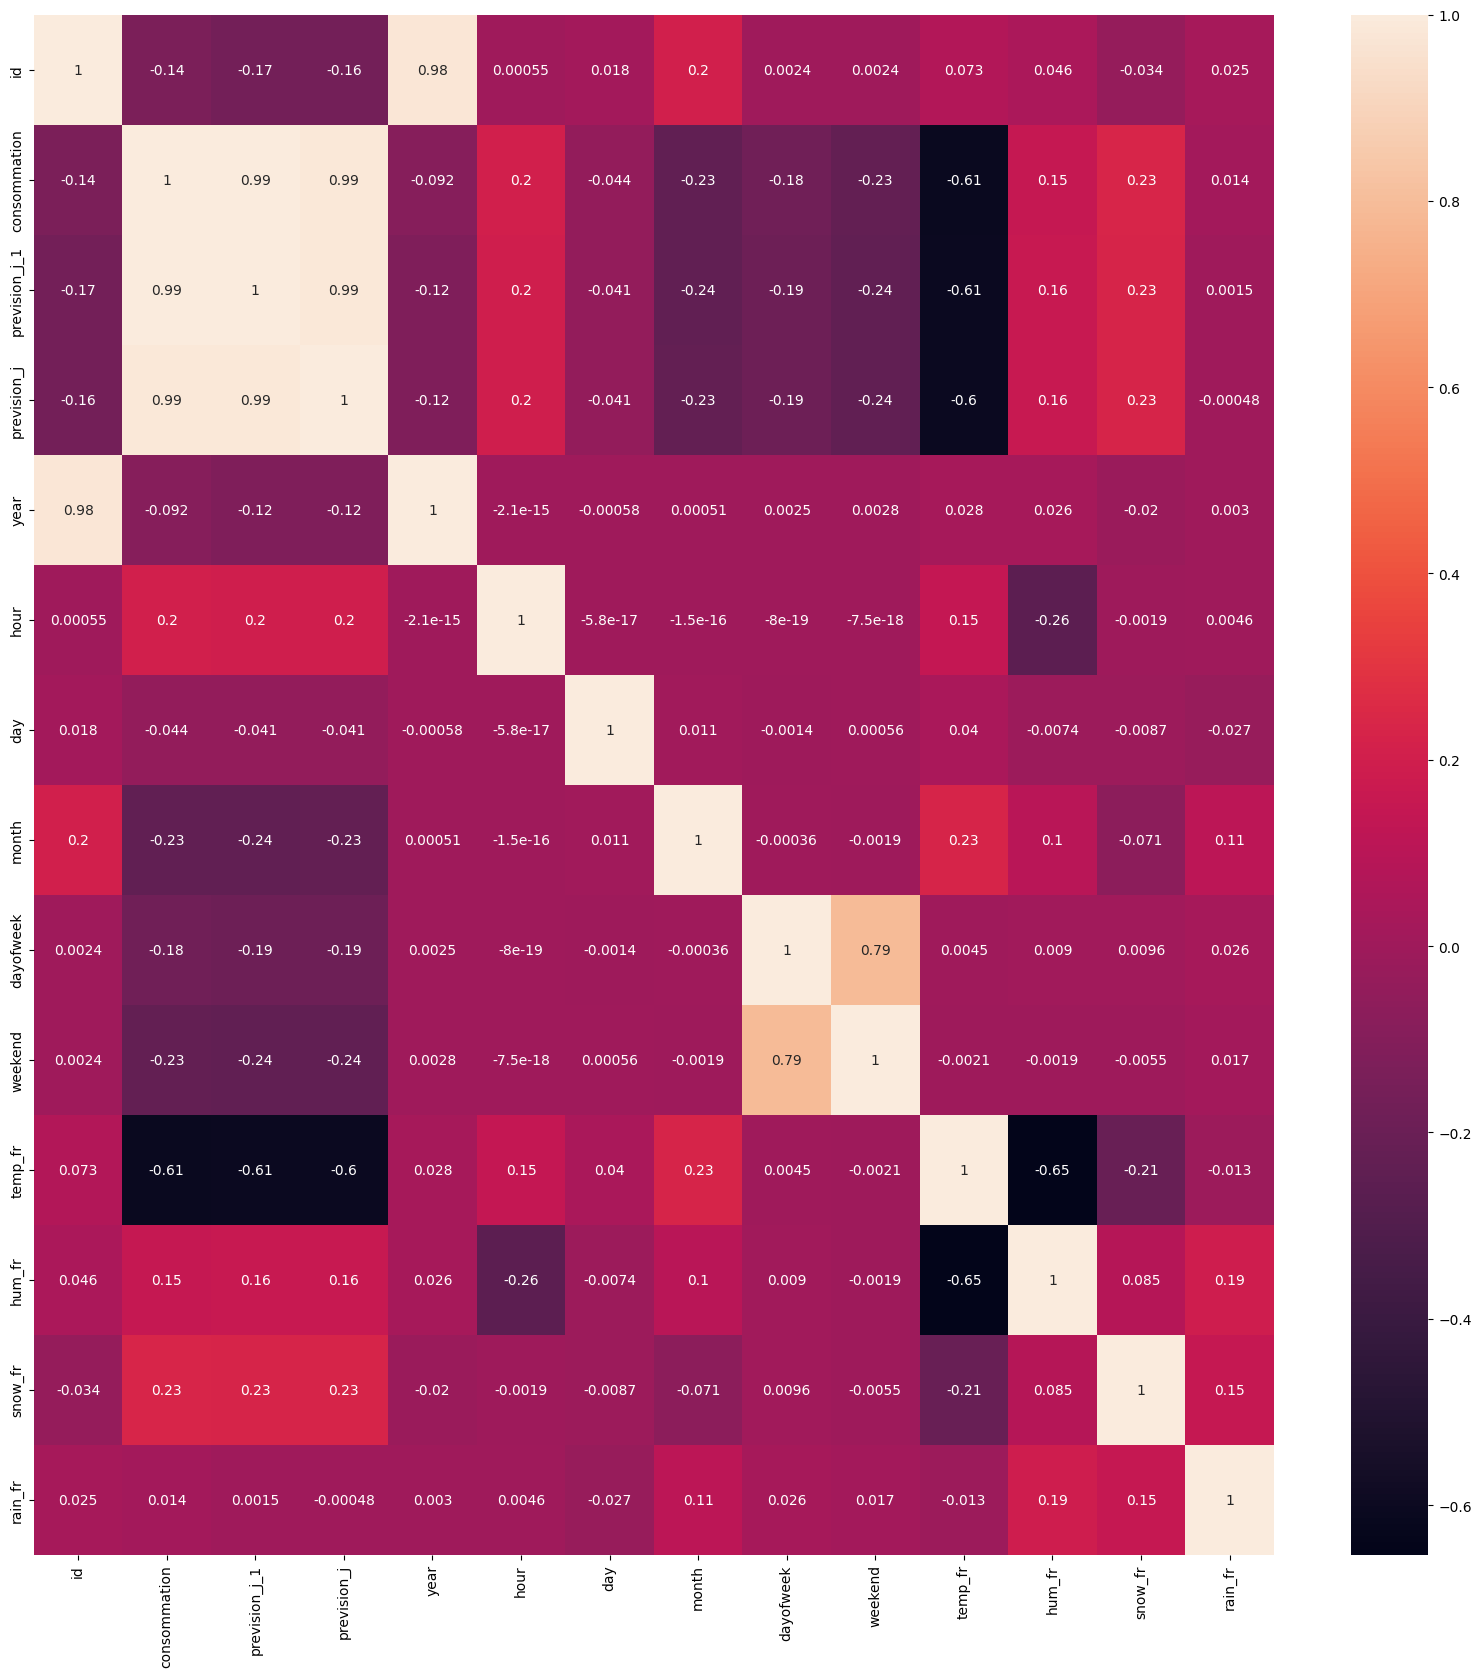

In [29]:
plt.figure(figsize = (20, 20))


corr = df_features.corr(numeric_only= True)

sns.heatmap(data = corr, annot = True)
plt.show()

### Plot target


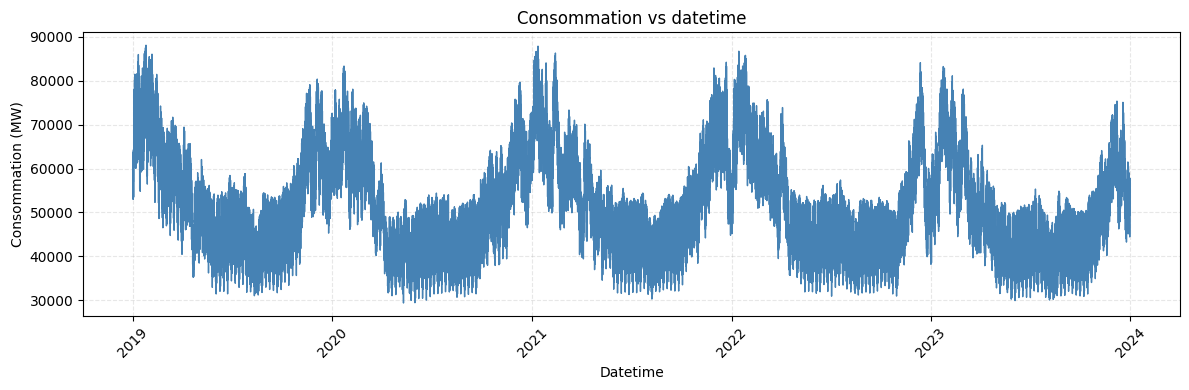

In [30]:
# Visualiser la consommation dans le temps
dt_index = pd.to_datetime({
    "year": df_features["year"],
    "month": df_features["month"],
    "day": df_features["day"],
    "hour": df_features["hour"],
}, errors="coerce")
plot_feature_over_time(dt_index, df_features["consommation"], 
                       "Consommation vs datetime", "Consommation (MW)", color="steelblue")

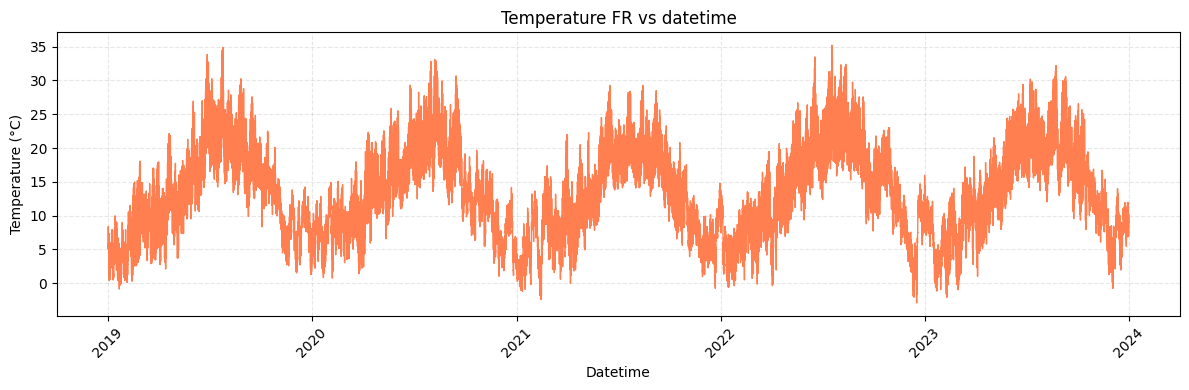

In [31]:
plot_feature_over_time(dt_index, df_features["temp_fr"], 
                       "Temperature FR vs datetime", "Temperature (°C)", color="coral")

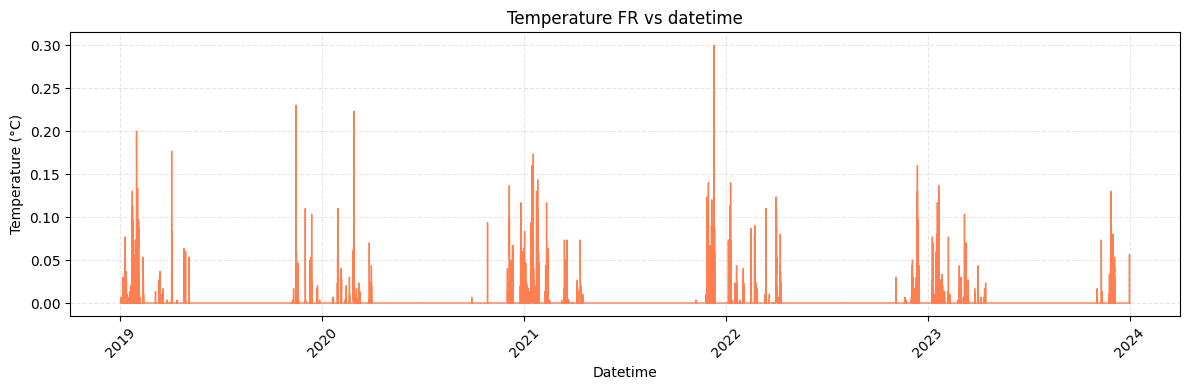

In [32]:
plot_feature_over_time(dt_index, df_features["snow_fr"], 
                       "Temperature FR vs datetime", "Temperature (°C)", color="coral")

In [33]:
df_features.columns

Index(['id', 'consommation', 'prevision_j_1', 'prevision_j', 'year', 'hour',
       'day', 'month', 'dayofweek', 'weekend', 'datetime', 'temp_fr', 'hum_fr',
       'snow_fr', 'rain_fr'],
      dtype='object')

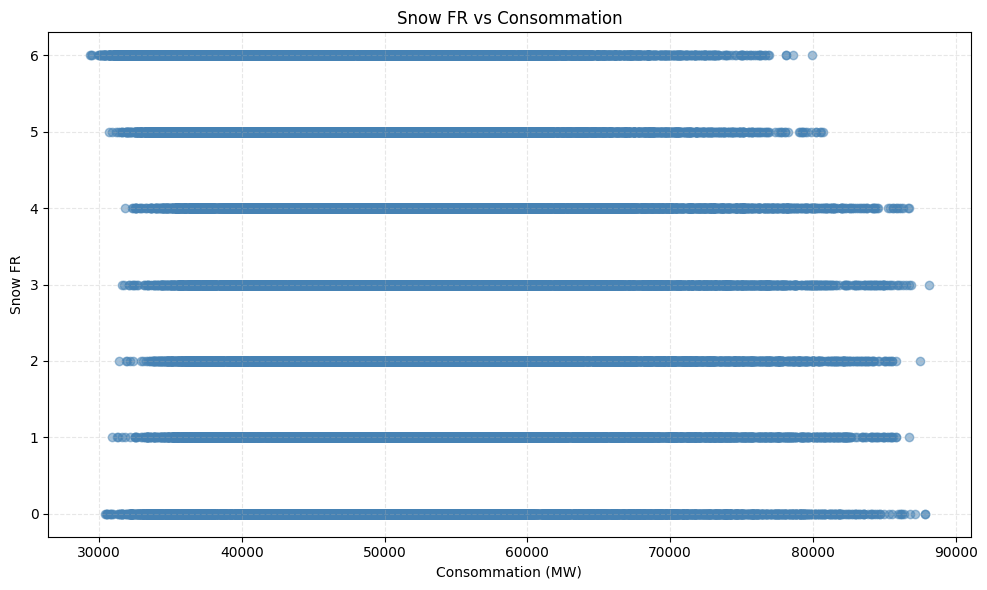

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_features["consommation"], df_features["dayofweek"], alpha=0.5, color="steelblue")
ax.set_ylabel("Snow FR")
ax.set_xlabel("Consommation (MW)")
ax.set_title("Snow FR vs Consommation")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

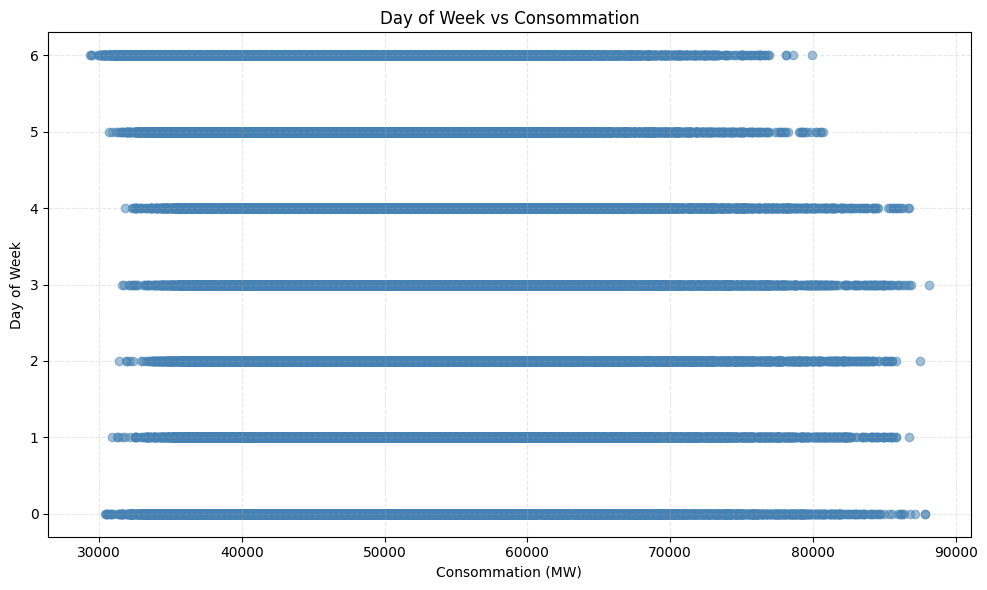

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_features["consommation"], df_features["dayofweek"], alpha=0.5, color="steelblue")
ax.set_ylabel("Day of Week")
ax.set_xlabel("Consommation (MW)")
ax.set_title("Day of Week vs Consommation")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

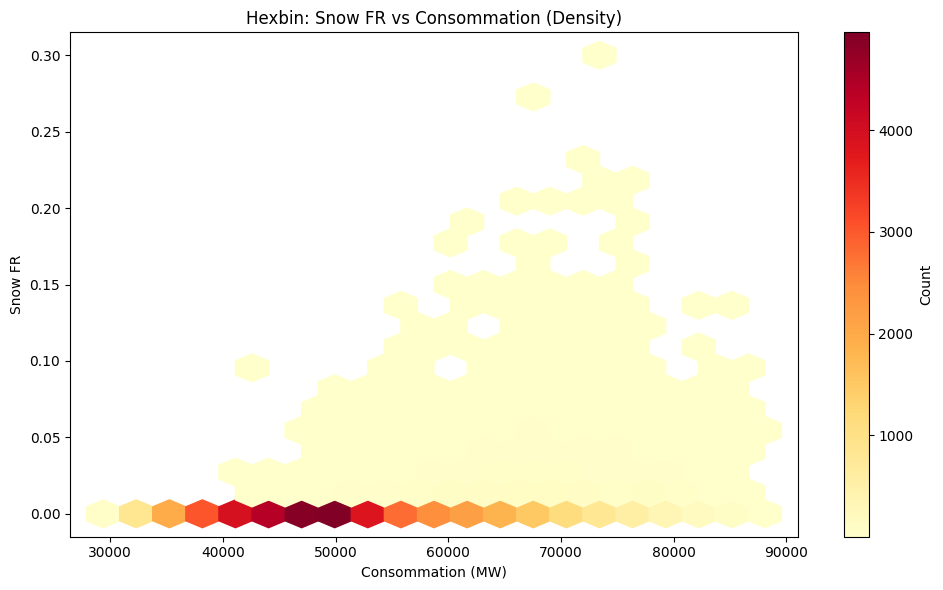

In [36]:
# Hexbin plot - Density visualization
fig, ax = plt.subplots(figsize=(10, 6))
hexbin = ax.hexbin(df_features["consommation"],df_features["snow_fr"], gridsize=20, cmap='YlOrRd', mincnt=1)
ax.set_ylabel("Snow FR")
ax.set_xlabel("Consommation (MW)")
ax.set_title("Hexbin: Snow FR vs Consommation (Density)")
plt.colorbar(hexbin, ax=ax, label='Count')
plt.tight_layout()

In [37]:
# Créer une copie pour ne pas modifier le dataframe original
df_corr = df_features.copy()

# Calculer les corrélations avec la cible
correlations = df_corr.corr()['consommation'].abs().sort_values(ascending=False)

# Retirer la corrélation de la cible avec elle-même et prendre les 8 premières
top_8_features = correlations.drop('consommation').head(8)

print("Les 8 features les plus corrélées avec 'consommation' sont :")
print(top_8_features)

Les 8 features les plus corrélées avec 'consommation' sont :
prevision_j_1    0.993994
prevision_j      0.986692
temp_fr          0.611520
month            0.234176
snow_fr          0.232464
weekend          0.228062
hour             0.200254
dayofweek        0.181287
Name: consommation, dtype: float64


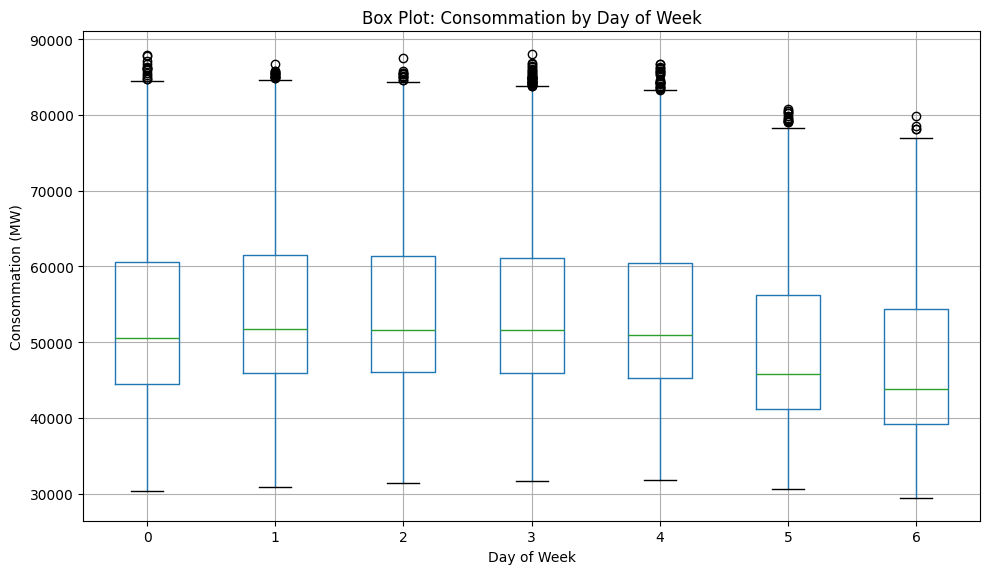

In [38]:
# Box plot - Distribution by day of week
fig, ax = plt.subplots(figsize=(10, 6))
df_features.boxplot(column='consommation', by='dayofweek', ax=ax)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Consommation (MW)")
ax.set_title("Box Plot: Consommation by Day of Week")
plt.suptitle('')
plt.tight_layout()

/tmp/ipykernel_556087/587066354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_features, x='dayofweek', y='consommation', ax=ax, palette='Set2')


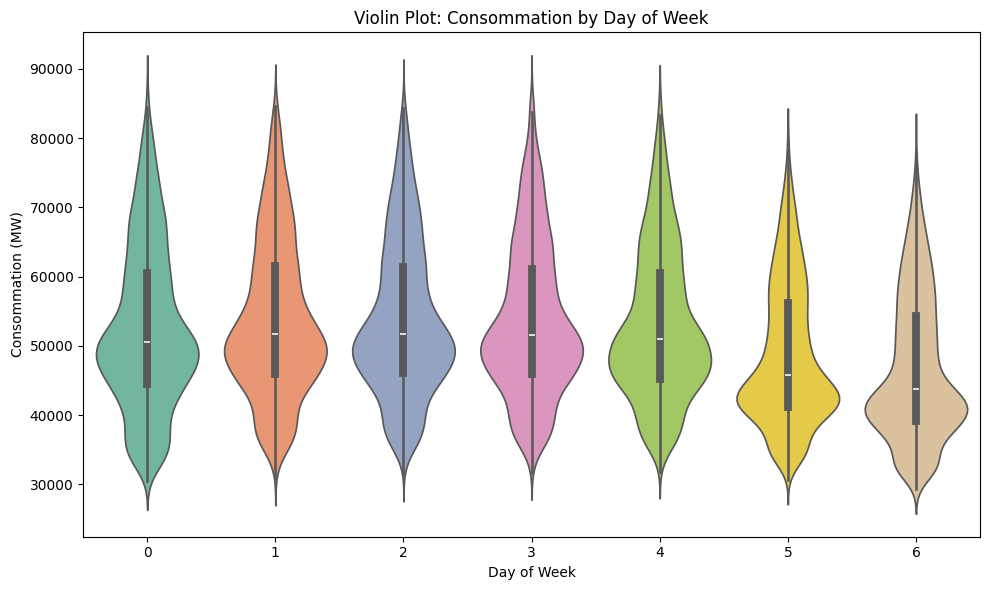

In [39]:
# Violin plot - Distribution comparison
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df_features, x='dayofweek', y='consommation', ax=ax, palette='Set2')
ax.set_xlabel("Day of Week")
ax.set_ylabel("Consommation (MW)")
ax.set_title("Violin Plot: Consommation by Day of Week")
plt.tight_layout()

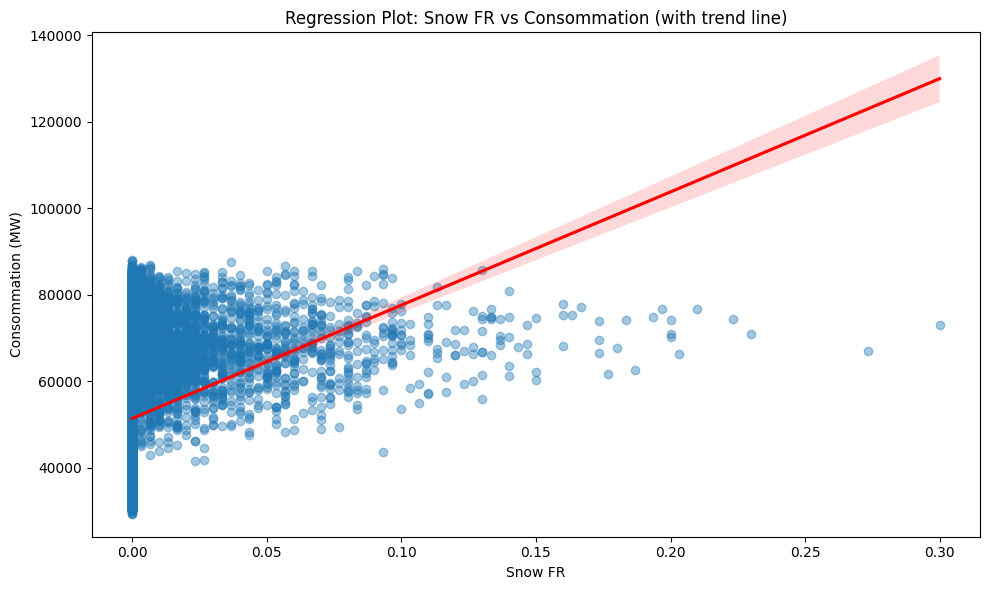

In [40]:
# Regression plot with KDE
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='snow_fr', y='consommation', data=df_features, ax=ax, scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
ax.set_xlabel("Snow FR")
ax.set_ylabel("Consommation (MW)")
ax.set_title("Regression Plot: Snow FR vs Consommation (with trend line)")
plt.tight_layout()

### Matrice de corrélation avec la variable cible

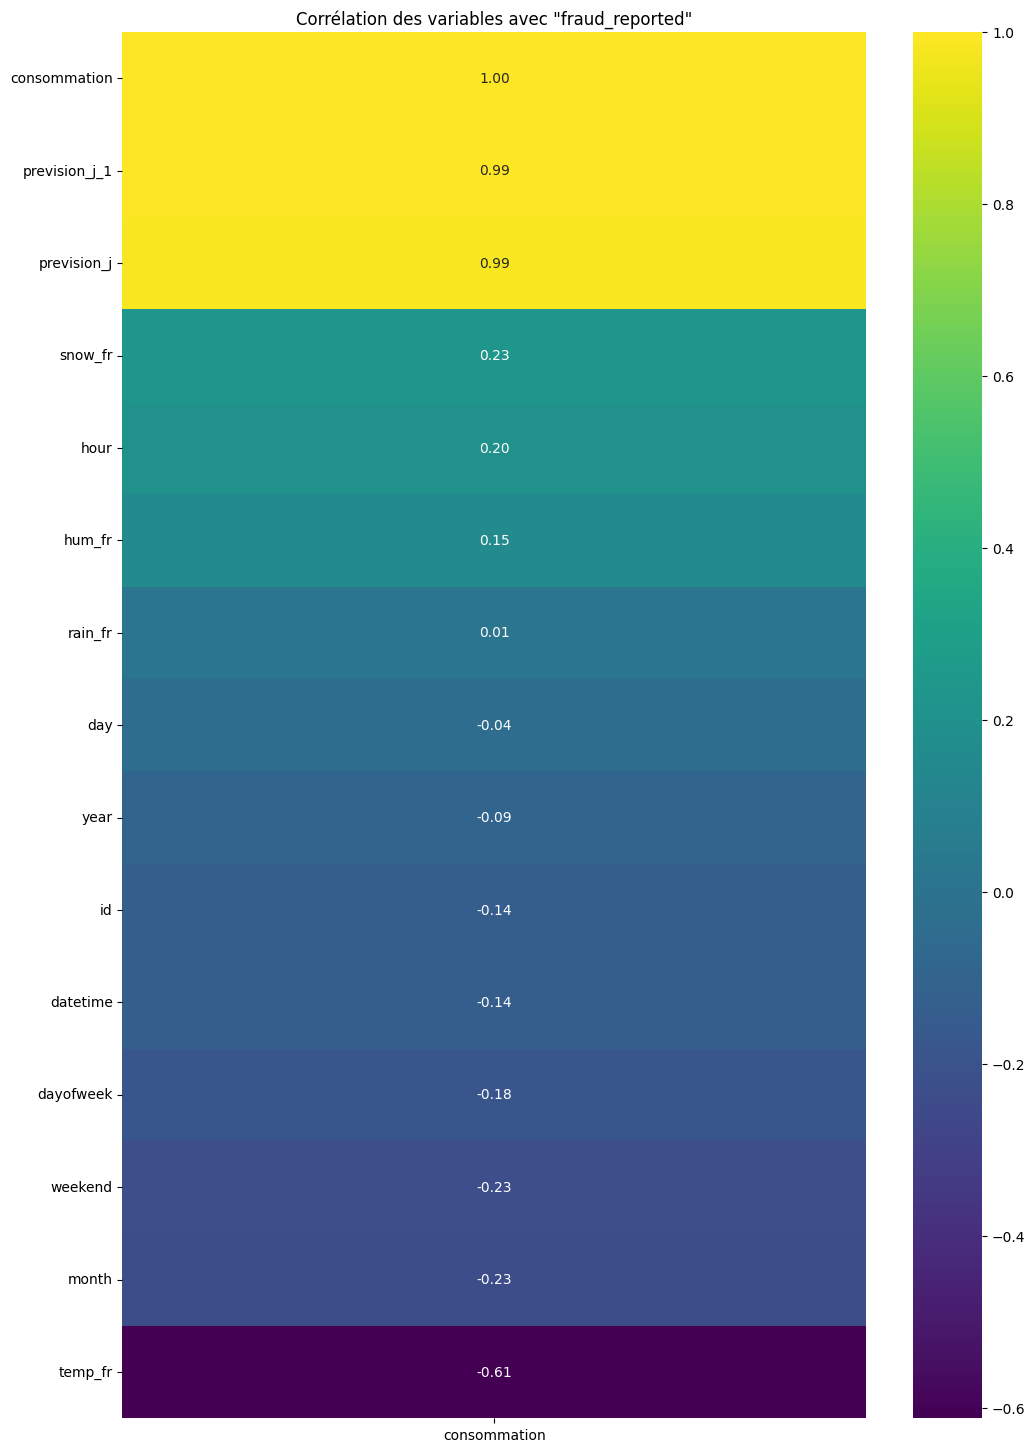

Top 10 des corrélations des features avec la cible (calculées sur le jeu d'entraînement) :
               consommation
consommation       1.000000
prevision_j_1      0.993994
prevision_j        0.986692
snow_fr            0.232464
hour               0.200254
hum_fr             0.153002
rain_fr            0.014283
day               -0.043793
year              -0.091562
id                -0.136426

/!\ ALERTE FUITE DE DONNÉES POTENTIELLE /!\
Les variables suivantes sont très fortement corrélées à la cible et doivent être examinées :
               consommation
consommation       1.000000
prevision_j_1      0.993994
prevision_j        0.986692
snow_fr                 NaN
hour                    NaN
hum_fr                  NaN
rain_fr                 NaN
day                     NaN
year                    NaN
id                      NaN
datetime                NaN
dayofweek               NaN
weekend                 NaN
month                   NaN
temp_fr                 NaN


In [41]:


# Calculer la corrélation de toutes les variables avec la variable cible
corr_target = df_corr.corr()[['consommation']].sort_values(by='consommation', ascending=False)

# Visualisation
plt.figure(figsize=(12, 18))
sns.heatmap(corr_target, annot=True, cmap='viridis', fmt=".2f")
plt.title('Corrélation des variables avec "fraud_reported"')
plt.show()



# Afficher les corrélations les plus élevées
print("Top 10 des corrélations des features avec la cible (calculées sur le jeu d'entraînement) :")
print(corr_target.head(10))

# Test : Identifier les fuites potentielles (corrélation > 0.9)
potential_leaks = corr_target[corr_target > 0.9]

if not potential_leaks.empty and 'fraud_reported' in potential_leaks:
    potential_leaks = potential_leaks.drop('fraud_reported') # Exclure la cible elle-même

if not potential_leaks.empty:
    print("\n/!\\ ALERTE FUITE DE DONNÉES POTENTIELLE /!\\")
    print("Les variables suivantes sont très fortement corrélées à la cible et doivent être examinées :")
    print(potential_leaks)
else:
    print("\n-> Aucune fuite de données évidente détectée via l'analyse de corrélation.")

In [42]:
df_features["hum_fr"].isna().value_counts()

hum_fr
False    43819
True         5
Name: count, dtype: int64

In [43]:
# Full rows where snow_fr is null
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
df_features[df_features["snow_fr"].isna()]

,id,consommation,prevision_j_1,prevision_j,year,hour,day,month,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
2138,2139,47533.5,47900.0,48400.0,2019,2,31,3,6,1,2019-03-31 02:00:00,NaN,NaN,NaN,NaN
10874,10875,47086.0,45300.0,46400.0,2020,2,29,3,6,1,2020-03-29 02:00:00,NaN,NaN,NaN,NaN
19610,19611,51975.0,51500.0,51900.0,2021,2,28,3,6,1,2021-03-28 02:00:00,NaN,NaN,NaN,NaN
28346,28347,46130.5,44700.0,44800.0,2022,2,27,3,6,1,2022-03-27 02:00:00,NaN,NaN,NaN,NaN
37082,37083,44920.0,42812.5,43812.5,2023,2,26,3,6,1,2023-03-26 02:00:00,NaN,NaN,NaN,NaN


In [44]:
# Drop rows with any nulls
df_features = df_features.dropna().reset_index(drop=True)

df_features.head()

,id,consommation,prevision_j_1,prevision_j,year,hour,day,month,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,1,63684.5,62987.5,62550.0,2019,0,1,1,1,0,2019-01-01 00:00:00,5.676690,90.987257,0.0,0.004762
1,2,60826.0,60837.5,60575.0,2019,1,1,1,1,0,2019-01-01 01:00:00,5.779071,90.525710,0.0,0.004762
2,3,59786.5,59500.0,58975.0,2019,2,1,1,1,0,2019-01-01 02:00:00,5.590976,90.401742,0.0,0.009524
3,4,56622.0,56012.5,55450.0,2019,3,1,1,1,0,2019-01-01 03:00:00,5.460024,90.541807,0.0,0.004762
4,5,53919.5,53300.0,53187.5,2019,4,1,1,1,0,2019-01-01 04:00:00,5.333833,90.940706,0.0,0.000000


In [45]:
# Search for NaN values in df_features
nan_counts = df_features.isna().sum().sort_values(ascending=False)
nan_counts

id               0
consommation     0
prevision_j_1    0
prevision_j      0
year             0
hour             0
day              0
month            0
dayofweek        0
weekend          0
datetime         0
temp_fr          0
hum_fr           0
snow_fr          0
rain_fr          0
dtype: int64

In [46]:
df_features.replace('?', np.nan, inplace=True)

# Drop variables too correlated with the target (data leakage)
df_features.drop(["prevision_j_1","prevision_j"], axis=1, inplace=True)

# Drop variables with low correlation with the target
df_features.drop(["day","id"], axis=1, inplace=True)

# Now separate features and target
X = df_features.drop('consommation', axis=1)
y = df_features['consommation']

In [47]:
X

,year,hour,month,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,2019,0,1,1,0,2019-01-01 00:00:00,5.676690,90.987257,0.000000,0.004762
1,2019,1,1,1,0,2019-01-01 01:00:00,5.779071,90.525710,0.000000,0.004762
2,2019,2,1,1,0,2019-01-01 02:00:00,5.590976,90.401742,0.000000,0.009524
3,2019,3,1,1,0,2019-01-01 03:00:00,5.460024,90.541807,0.000000,0.004762
4,2019,4,1,1,0,2019-01-01 04:00:00,5.333833,90.940706,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
43814,2023,19,12,6,1,2023-12-31 19:00:00,7.505262,78.402122,0.010000,0.157143
43815,2023,20,12,6,1,2023-12-31 20:00:00,7.271929,78.441276,0.056667,0.157143
43816,2023,21,12,6,1,2023-12-31 21:00:00,7.207643,78.287450,0.010000,0.042857
43817,2023,22,12,6,1,2023-12-31 22:00:00,7.186214,77.733249,0.000000,0.009524


In [48]:
# Search for NaN values in df_features
nanX_counts = X.isna().sum().sort_values(ascending=False)
nanX_counts

year         0
hour         0
month        0
dayofweek    0
weekend      0
datetime     0
temp_fr      0
hum_fr       0
snow_fr      0
rain_fr      0
dtype: int64

In [49]:
y

0        63684.5
1        60826.0
2        59786.5
3        56622.0
4        53919.5
          ...   
43814    57746.5
43815    55546.0
43816    53570.5
43817    53118.5
43818    55420.5
Name: consommation, Length: 43819, dtype: float64

In [50]:
TRAIN_YEARS = [2019, 2020, 2021]
TEST_YEARS = [2022]

# Séparer train/test par années
if "year" not in X.columns:
    raise ValueError("La colonne 'year' est requise pour la séparation train/test par années.")

X_train = X[X["year"].isin(TRAIN_YEARS)].copy()
X_test = X[X["year"].isin(TEST_YEARS)].copy()
y_train = y.loc[X_train.index].copy()
y_test = y.loc[X_test.index].copy()


In [51]:
X_train

,year,hour,month,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,2019,0,1,1,0,2019-01-01 00:00:00,5.676690,90.987257,0.0,0.004762
1,2019,1,1,1,0,2019-01-01 01:00:00,5.779071,90.525710,0.0,0.004762
2,2019,2,1,1,0,2019-01-01 02:00:00,5.590976,90.401742,0.0,0.009524
3,2019,3,1,1,0,2019-01-01 03:00:00,5.460024,90.541807,0.0,0.004762
4,2019,4,1,1,0,2019-01-01 04:00:00,5.333833,90.940706,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
26296,2021,19,12,4,0,2021-12-31 19:00:00,9.848119,91.007437,0.0,0.000000
26297,2021,20,12,4,0,2021-12-31 20:00:00,9.583833,90.284346,0.0,0.000000
26298,2021,21,12,4,0,2021-12-31 21:00:00,9.195738,90.398111,0.0,0.000000
26299,2021,22,12,4,0,2021-12-31 22:00:00,8.888595,90.154940,0.0,0.000000


In [52]:

# Retirer les colonnes non numériques / non pertinentes pour l'entraînement
drop_cols = [col for col in ["year", "datetime"] if col in X_train.columns]
X_train_num = X_train.drop(drop_cols, axis=1)
X_test_num = X_test.drop(drop_cols, axis=1)

# 2. Définir les pipelines de transformation
numeric_features = X_train_num.select_dtypes(include=np.number).columns
print(" ------------- numeric_features ------------- ")
print(numeric_features.tolist())

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop',
)

# 3. Pré-traiter X_train et identifier les 8 meilleures features
# On ajuste ET transforme X_train
X_train_processed = preprocessor.fit_transform(X_train_num)
X_test_processed = preprocessor.transform(X_test_num)

 ------------- numeric_features ------------- 
['hour', 'month', 'dayofweek', 'weekend', 'temp_fr', 'hum_fr', 'snow_fr', 'rain_fr']


In [53]:
df_features["snow_fr"].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
43814    False
43815    False
43816    False
43817    False
43818    False
Name: snow_fr, Length: 43819, dtype: bool

In [54]:
df_features.isna().value_counts()

consommation  year   hour   month  dayofweek  weekend  datetime  temp_fr  hum_fr  snow_fr  rain_fr
False         False  False  False  False      False    False     False    False   False    False      43819
Name: count, dtype: int64

In [55]:
corr_target

,consommation
consommation,1.000000
prevision_j_1,0.993994
prevision_j,0.986692
snow_fr,0.232464
hour,0.200254
hum_fr,0.153002
rain_fr,0.014283
day,-0.043793
year,-0.091562
id,-0.136426


In [56]:
df_features.head()

,consommation,year,hour,month,dayofweek,weekend,datetime,temp_fr,hum_fr,snow_fr,rain_fr
0,63684.5,2019,0,1,1,0,2019-01-01 00:00:00,5.676690,90.987257,0.0,0.004762
1,60826.0,2019,1,1,1,0,2019-01-01 01:00:00,5.779071,90.525710,0.0,0.004762
2,59786.5,2019,2,1,1,0,2019-01-01 02:00:00,5.590976,90.401742,0.0,0.009524
3,56622.0,2019,3,1,1,0,2019-01-01 03:00:00,5.460024,90.541807,0.0,0.004762
4,53919.5,2019,4,1,1,0,2019-01-01 04:00:00,5.333833,90.940706,0.0,0.000000


In [57]:
numeric_features

Index(['hour', 'month', 'dayofweek', 'weekend', 'temp_fr', 'hum_fr', 'snow_fr',
       'rain_fr'],
      dtype='object')

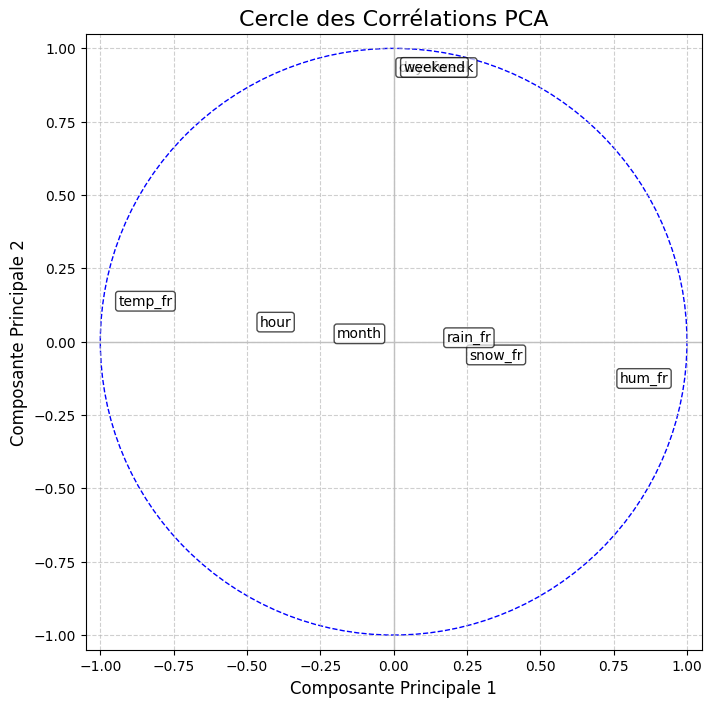

In [58]:
# Using X_train for the analysis
#features_for_pca = df_featurenumeric_features[['snow_fr','hour','temp_fr','month','weekend','dayofweek']]

features_for_pca = df_features[numeric_features].copy()

data_scaled_df = pd.DataFrame(features_for_pca, columns=features_for_pca.columns)

# Performing PCA with prince
pca = prince.PCA(
    n_components=len(features_for_pca.columns),
    rescale_with_mean=True,
    rescale_with_std=True,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=SEED
)

pca = pca.fit(data_scaled_df)

# Calling the plot function
f_plot_circle(pca, features_for_pca)

## Entrainement et Test

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

def train_models(X, y):
    models = {
        "LinearRegression": LinearRegression(),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        "KNN": KNeighborsRegressor(n_neighbors=7),
    }

    trained = {}
    for name, model in models.items():
        model.fit(X, y)
        trained[name] = model
    return trained


In [60]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps = 1e-9
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (%)": mape(y_test, y_pred),
    }


In [61]:
models = train_models(X_train_processed, y_train)

best_name, best_model, best_r2 = None, None, -999
for name, model in models.items():
    metrics = evaluate_model(model, X_test_processed, y_test)
    print(f"Modèle : {name}")
    for k, v in metrics.items():
        print(f"{k} : {v:.4f}")

    if metrics["R2"] > best_r2:
        best_r2 = metrics["R2"]
        best_name, best_model = name, model

Modèle : LinearRegression
R2 : 0.6118
RMSE : 7087.1009
MAPE (%) : 11.4878
Modèle : RandomForest
R2 : 0.8928
RMSE : 3724.2486
MAPE (%) : 5.2426
Modèle : KNN
R2 : 0.8589
RMSE : 4272.4468
MAPE (%) : 6.2132


### 📐 Interprétation Métriques

- **R2** : Pourcentage de Performance 
- **RMSE** : Plus gros écart entre la valeur prédite et la valeur de référence
- **MAPE** : Pourcentage du plus gros écart entre la valeur prédite et la valeur de référence

## Notes
- Regression Polynomiale (très expliquable)
- Prophet, ARIMA, Holt-Winters (recommandé)
- RNN(LSTM)
- Perceptron Multi-Couche
- ARDL

### Model Analysis

In [62]:
# Zoomable line chart for y_true and y_pred (Plotly Express style)
import plotly.express as px

y_pred = best_model.predict(X_test_processed)
y_true = pd.Series(y_test).reset_index(drop=True)
y_pred_series = pd.Series(y_pred).reset_index(drop=True)

plot_df = pd.DataFrame({
    "sample": y_true.index,
    "y_true": y_true.values,
    "y_pred": y_pred_series.values,
})
plot_long = plot_df.melt(id_vars="sample", var_name="series", value_name="value")

fig = px.line(plot_long, x="sample", y="value", color="series")
fig.update_layout(
    title="y_true vs y_pred",
    xaxis_title="Sample",
    yaxis_title="Consommation",
    hovermode="x"
)
fig.show()

#### Monthly metrics by year

Compare R2, RMSE, and MAPE by month for each year and plot the monthly average of y_true (consommation).

/tmp/ipykernel_556087/779082112.py:49: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,year,month,R2,RMSE,MAPE (%)
0,2022,1,0.778808,4108.607044,4.591641
1,2022,2,0.701721,3061.980838,3.814884
2,2022,3,0.673357,3841.971604,4.809381
3,2022,4,0.678785,4642.536218,6.707225
4,2022,5,0.671983,3063.554505,4.892225
5,2022,6,0.936682,1463.966602,2.102269
6,2022,7,0.919131,1677.512935,2.598963
7,2022,8,0.910505,1653.272321,2.717329
8,2022,9,0.892111,1827.953707,3.199854
9,2022,10,0.236093,4520.335864,9.768277


/tmp/ipykernel_556087/779082112.py:67: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,year,R2,RMSE,MAPE (%)
0,2022,0.892805,3724.248629,5.242615


/tmp/ipykernel_556087/779082112.py:81: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




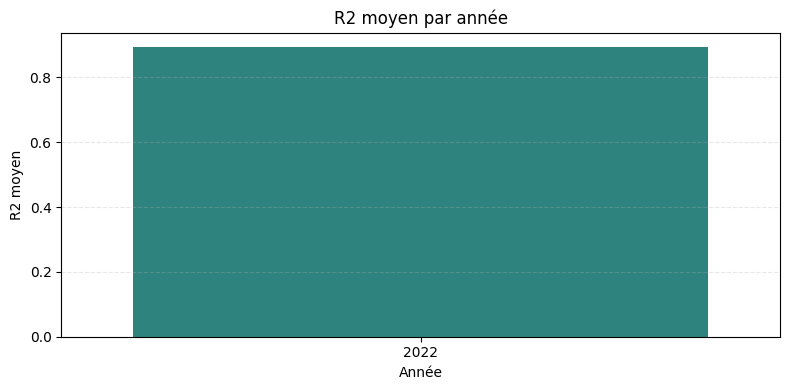

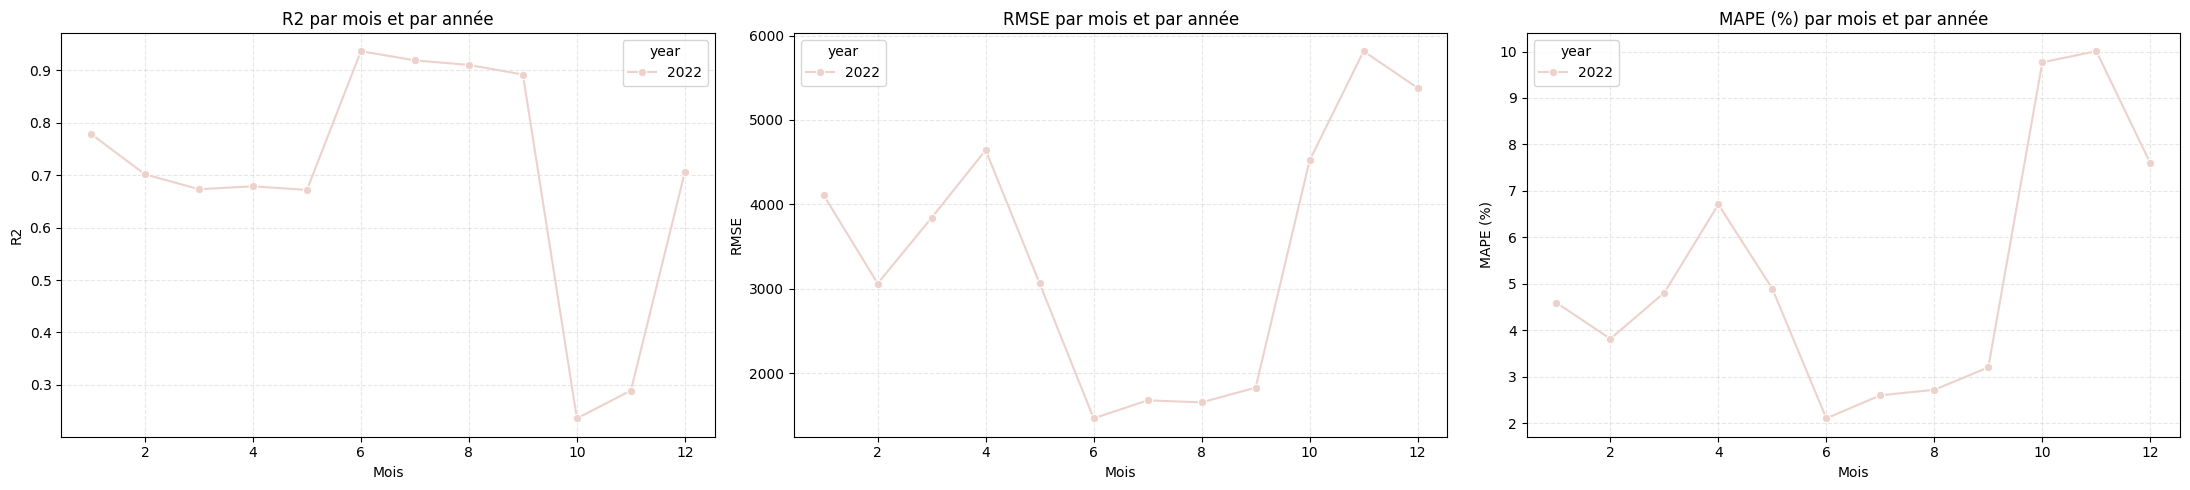

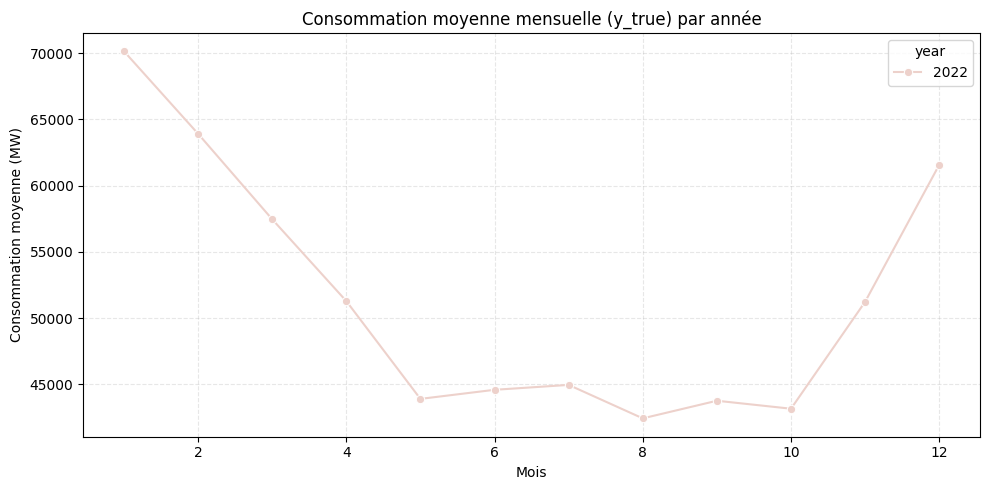

In [63]:
# Build evaluation dataframe with datetime, y_true, y_pred
if "datetime" in X_test.columns:
    dt_eval = pd.to_datetime(X_test["datetime"], errors="coerce")
elif {"year", "month", "day", "hour"}.issubset(X_test.columns):
    dt_eval = pd.to_datetime(
        {
            "year": X_test["year"],
            "month": X_test["month"],
            "day": X_test["day"],
            "hour": X_test["hour"],
        },
        errors="coerce",
    )
elif {"year", "month", "day", "hour"}.issubset(df_features.columns):
    tmp_dt = df_features.loc[X_test.index]
    dt_eval = pd.to_datetime(
        {
            "year": tmp_dt["year"],
            "month": tmp_dt["month"],
            "day": tmp_dt["day"],
            "hour": tmp_dt["hour"],
        },
        errors="coerce",
    )
else:
    raise ValueError("Datetime columns not found for monthly evaluation.")

y_true_eval = pd.Series(y_test, index=X_test.index, name="y_true")
y_pred_eval = pd.Series(best_model.predict(X_test_processed), index=X_test.index, name="y_pred")

eval_df = pd.concat([dt_eval.rename("datetime"), y_true_eval, y_pred_eval], axis=1).dropna()
eval_df["year"] = eval_df["datetime"].dt.year
eval_df["month"] = eval_df["datetime"].dt.month

def _mape(y_true_vals, y_pred_vals):
    y_true_vals = np.asarray(y_true_vals, dtype=float)
    y_pred_vals = np.asarray(y_pred_vals, dtype=float)
    eps = 1e-9
    return np.mean(np.abs((y_true_vals - y_pred_vals) / (y_true_vals + eps))) * 100

def _r2(y_true_vals, y_pred_vals):
    return r2_score(y_true_vals, y_pred_vals) if len(y_true_vals) > 1 else np.nan

def _rmse(y_true_vals, y_pred_vals):
    return np.sqrt(mean_squared_error(y_true_vals, y_pred_vals)) if len(y_true_vals) > 0 else np.nan

metrics_by_month = (
    eval_df.groupby(["year", "month"])
    .apply(
        lambda g: pd.Series(
            {
                "R2": _r2(g["y_true"], g["y_pred"]),
                "RMSE": _rmse(g["y_true"], g["y_pred"]),
                "MAPE (%)": _mape(g["y_true"], g["y_pred"]),
            }
        )
    )
    .reset_index()
    .sort_values(["year", "month"])
)

display(metrics_by_month)

# R2 by year (computed on all rows of each year, not monthly mean)
yearly_r2_df = (
    eval_df.groupby("year")
    .apply(lambda g: pd.Series(
        {
            "R2": _r2(g["y_true"], g["y_pred"]),
            "RMSE": _rmse(g["y_true"], g["y_pred"]),
            "MAPE (%)": _mape(g["y_true"], g["y_pred"]),
        }
    ))
    .reset_index()
    .sort_values("year")
)
display(yearly_r2_df)


plt.figure(figsize=(8, 4))
sns.barplot(data=yearly_r2_df, x="year", y="R2", palette="viridis")
plt.title("R2 moyen par année")
plt.xlabel("Année")
plt.ylabel("R2 moyen")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot metrics by month for each year
fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharex=True)
sns.lineplot(data=metrics_by_month, x="month", y="R2", hue="year", marker="o", ax=axes[0])
axes[0].set_title("R2 par mois et par année")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("R2")
axes[0].grid(True, linestyle="--", alpha=0.3)

sns.lineplot(data=metrics_by_month, x="month", y="RMSE", hue="year", marker="o", ax=axes[1])
axes[1].set_title("RMSE par mois et par année")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, linestyle="--", alpha=0.3)

sns.lineplot(data=metrics_by_month, x="month", y="MAPE (%)", hue="year", marker="o", ax=axes[2])
axes[2].set_title("MAPE (%) par mois et par année")
axes[2].set_xlabel("Mois")
axes[2].set_ylabel("MAPE (%)")
axes[2].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Plot monthly average of y_true (consommation) by year
monthly_true = (
    eval_df.groupby(["year", "month"])["y_true"].mean().reset_index().sort_values(["year", "month"])
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_true, x="month", y="y_true", hue="year", marker="o")
plt.title("Consommation moyenne mensuelle (y_true) par année")
plt.xlabel("Mois")
plt.ylabel("Consommation moyenne (MW)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
y_true

0       54299.0
1       52137.5
2       51487.0
3       48817.5
4       46627.0
         ...   
8754    50493.5
8755    48413.5
8756    46100.5
8757    45342.5
8758    47517.0
Name: consommation, Length: 8759, dtype: float64

## Notes

- Apprentissage sur 4 années
- Test sur 1 mois
- Puis Ré Apprentissage 4 ans + 1 mois (pas conservation du modèle) (ne pas donner les prédictions)
- R2 / RMSE Surtout
- UI Final avec les temp et les features COmmparsion avec le y prédit et y true
- R2 > 0,80 Est bon pour la prod

In [65]:
import plotly.express as px

df_plot = pd.DataFrame({
    "sample": y_true.index,
    "y_true": y_true.values,
    "y_pred": y_pred_series.values,
})
df_long = df_plot.melt(id_vars="sample", value_vars=["y_true", "y_pred"], var_name="series", value_name="value")

fig = px.line(df_long, x="sample", y="value", color="series", title="y_true vs y_pred")
fig.show()

In [66]:
models = train_models(X_train_processed, y_train)

best_name, best_model, best_r2 = None, None, -999
for name, model in models.items():
    metrics = evaluate_model(model, X_test_processed, y_test)
    print(f"Modèle : {name}")
    for k, v in metrics.items():
        print(f"{k} : {v:.4f}")

    if metrics["R2"] > best_r2:
        best_r2 = metrics["R2"]
        best_name, best_model = name, model

Modèle : LinearRegression
R2 : 0.6118
RMSE : 7087.1009
MAPE (%) : 11.4878
Modèle : RandomForest
R2 : 0.8928
RMSE : 3724.2486
MAPE (%) : 5.2426
Modèle : KNN
R2 : 0.8589
RMSE : 4272.4468
MAPE (%) : 6.2132
